## Logistic Regression Exercise - Movies

In [50]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.base.model import GenericLikelihoodModel

**Part 1: Load and explore**

1. Load the dataset and display the first few rows.  
2. How many movies in the dataset were nominated for Best Picture?  
3. What percentage of movies were nominated?  
4. Compute the average revenue for:  
    * nominated movies  
    * non-nominated movies  
Does revenue look associated with nominations?

In [2]:
movies = pd.read_csv('../data/movies.csv')
movies.head(2)

,Title,Year,Vote_Average,Vote_Count,Budget,Revenue,TMDB_ID,Nominee,Winner,Genre_Action,...,Genre_History,Genre_Horror,Genre_Music,Genre_Mystery,Genre_Romance,Genre_Science Fiction,Genre_TV Movie,Genre_Thriller,Genre_War,Genre_Western
0,#Alive,2020,7.228,1956,6300000,13416285,614696,0,0,True,...,False,True,False,False,False,True,False,False,False,False
1,10 Cloverfield Lane,2016,6.994,8359,15000000,110216998,333371,0,0,False,...,False,True,False,False,False,True,False,True,False,False


In [3]:
num_nominees = movies.value_counts('Nominee')[1]
print(f'{num_nominees} out of the {len(movies)} movies in our dataset were nominated for a Best Picture Academy Award.')

91 out of the 1005 movies in our dataset were nominated for a Best Picture Academy Award.


In [4]:
prop_nominees = movies.value_counts('Nominee')[1]/len(movies)
print(f'{prop_nominees*100:.2f}% of the movies in our dataset were nominated for a Best Picture Academy Award.')

9.05% of the movies in our dataset were nominated for a Best Picture Academy Award.


In [5]:
rev_by_nominee = movies.groupby('Nominee').agg({'Revenue':'mean'})

In [6]:
print(f'The average revenue for a movie NOT nominated for a Best Picture award is ${rev_by_nominee.loc[0,'Revenue']:,.2f}.')

The average revenue for a movie NOT nominated for a Best Picture award is $189,624,332.38.


In [7]:
print(f'The average revenue for a movie nominated for a Best Picture award is ${rev_by_nominee.loc[1,'Revenue']:,.2f}.')

The average revenue for a movie nominated for a Best Picture award is $232,573,777.25.


In [8]:
rev_by_nominee.loc[1,'Revenue']/rev_by_nominee.loc[0,'Revenue']

np.float64(1.2264975403142884)

On average, a movie that is nominated for a Best Picture will earn about 23% more revenue than a movie that is not nominated. There does seem to be a relationship between Best Picture nominee status and revenue.

**Part 2: Logistic Regression: Revenue Only**

5. Fit a logistic regression model for whether a movie was nominated based on its revenue.  
6. Interpret the sign of the coefficient for Revenue.  
7. Use the model to estimate the probability of nomination for a movie with \\$10M revenue, \\$100M revenue, and \\$500M revenue.  
8. Make a plot of predicted probability vs. revenue.

In [73]:
# Drop movies with zero revenue or zero budget
movies = movies[(movies['Revenue'] != 0) | (movies['Budget'] != 0)]

In [10]:
nominee_rev_logreg = smf.logit("Nominee ~ Revenue",
                          data = movies).fit()

Optimization terminated successfully.
         Current function value: 0.339034
         Iterations 6


In [11]:
nominee_rev_logreg.params

Intercept   -2.139634e+00
Revenue      5.196402e-11
dtype: float64

The positive Revenue coefficient indicates that as revenue increases, a Best Picture nomination is more likely. 

In [12]:
def logistic(x):
    return 1 / (1 + np.exp(-x))

In [13]:
# Takes in a movie revenue value, in millions of USD, and calculates the probability of a Best Picture nomination
def nominee_prediction(rev):
    logit_p = nominee_rev_logreg.params['Intercept'] + nominee_rev_logreg.params['Revenue']*rev*1000000
    print(f'Estimated Probability of Best Picture Nomination for a movie with ${rev}M in revenue: {logistic(logit_p):.3f}')

In [14]:
nominee_prediction(10)

Estimated Probability of Best Picture Nomination for a movie with $10M in revenue: 0.105


In [15]:
nominee_prediction(100)

Estimated Probability of Best Picture Nomination for a movie with $100M in revenue: 0.106


In [16]:
nominee_prediction(500)

Estimated Probability of Best Picture Nomination for a movie with $500M in revenue: 0.108


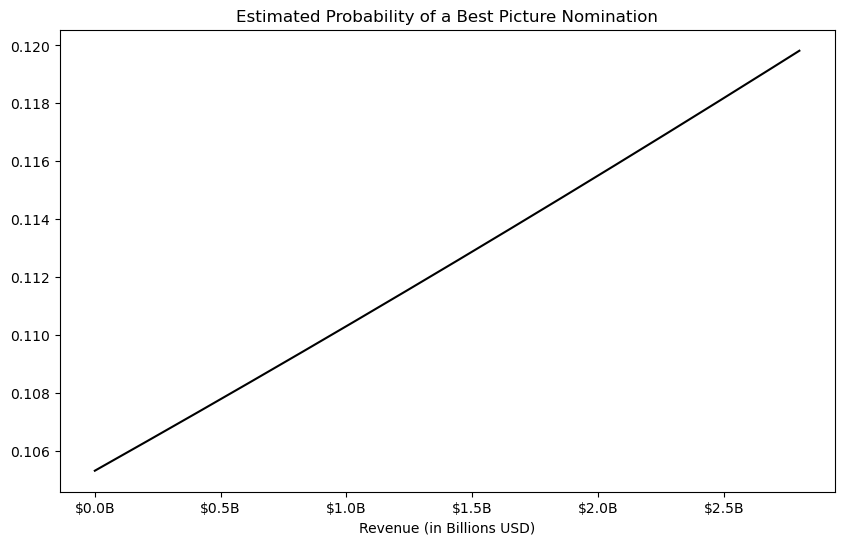

In [17]:
fit_df = pd.DataFrame({
    'Revenue': np.linspace(start = movies['Revenue'].min(),
                            stop = movies['Revenue'].max(),
                            num = 150)
})

fit_df['fit'] = nominee_rev_logreg.predict(fit_df)

ax = fit_df.plot(x = 'Revenue',
             y = 'fit',
             legend = False,
             figsize = (10,6),
             color = 'black',
            title = 'Estimated Probability of a Best Picture Nomination',
             xlabel = 'Revenue (in Billions USD)');
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,pos: '$'+format(x/1000000000,'1.1f')+'B'))

**Part 3: Add Genre**

9. Fit a model for whether a movie was nominated based on its revenue and whether or not it is a drama.  
10. Interpret the coefficient for Genre_Drama. 
11. Using your final model, compute the predicted probabilities of nominations for:  
    * \\$20M non-drama
    * \\$20M drama
    * \\$300M non-drama
    * \\$300M drama  
12. Which variable has the larger effect: being a drama or revenue?

In [18]:
nominee_rev_drama_logreg = smf.logit("Nominee ~ Revenue + Genre_Drama",
                          data = movies).fit()

Optimization terminated successfully.
         Current function value: 0.260833
         Iterations 8


In [19]:
nominee_rev_drama_logreg.params

Intercept             -4.509710e+00
Genre_Drama[T.True]    3.281421e+00
Revenue                1.457453e-09
dtype: float64

The positive coefficient for Genre_Drama indicates that a movie being a Drama increases the probability that it will be nominated for a Best Picture award. 

In [20]:
# Take e to the power of the coefficient to obtain the odds ratio
np.exp(nominee_rev_drama_logreg.params['Genre_Drama[T.True]'])

np.float64(26.613567167322955)

The value of the coefficient for Genre_Drama indicates that dramas have 28 times the odds of being nominated for a Best Picture than other movie genres. 

In [21]:
# Takes in a movie revenue value, in millions of USD, and a drama value (0 or 1) and calculates the probability of a Best Picture nomination
def nominee_prediction_with_drama(rev,drama):
    drama_value=['drama' if drama==1 else 'non-drama']
    logit_p = nominee_rev_drama_logreg.params['Intercept'] + nominee_rev_drama_logreg.params['Revenue']*rev*1000000 + nominee_rev_drama_logreg.params['Genre_Drama[T.True]']*drama
    print(f'Estimated Probability of Best Picture Nomination for a {drama_value[0]} with ${rev}M in revenue: {logistic(logit_p):.2f}')

In [22]:
nominee_prediction_with_drama(20,0)

Estimated Probability of Best Picture Nomination for a non-drama with $20M in revenue: 0.01


In [23]:
nominee_prediction_with_drama(20,1)

Estimated Probability of Best Picture Nomination for a drama with $20M in revenue: 0.23


In [24]:
nominee_prediction_with_drama(300,0)

Estimated Probability of Best Picture Nomination for a non-drama with $300M in revenue: 0.02


In [25]:
nominee_prediction_with_drama(300,1)

Estimated Probability of Best Picture Nomination for a drama with $300M in revenue: 0.31


A movie being a drama increases the log odds of the probability of being nominated for a Best Picture by about 3.28 (i.e. it multiplies the odds of being nominated for a Best Picture by e<sup>3.28</sup> $\approx$ 26.61). 

A \$1M increase in movie revenue increases the log odds of being nominated for a Best Picture by about 0.001457 (i.e. it multiplies the odds of being nominated for a Best Picture by e<sup>0.001457</sup> $\approx$ 1.001458). 

A movie being a drama has a much greater effect on its chance of being nominated for a Best Picture compared with the effect of revenue. A \\$2.251B increase in movie revenue would be needed to have the same effect as a movie being a drama. ($3.34/0.001727 \approx 2,251$)


**Part 4: Stretch Questions**  

13. How do the empirical and estimated probabilities look for the revenue-only model? What about the model that uses both revenue and the drama genre?    
14. Revenue is highly skewed, which means that log revenue might make for a better model fit. Try fitting a model using log revenue. Then compare these models. You can look at [Akaike Information Criterion](https://en.wikipedia.org/wiki/Akaike_information_criterion) or the [log-likelihood](https://en.wikipedia.org/wiki/Likelihood_function). You might also look at a [calibration curve](https://encord.com/glossary/calibration-curve/).  
15. Add other genres to your model. Which genres have the largest effect on the estimated probability of being nominated?  
16. Instead of revenue, use profit. How does this change the model?

In [26]:
# Empirical and estimated probabilities for revenue-only model 
nominee_summary = (
    movies
    .assign(Group = pd.qcut(movies['Revenue'], 
                            q = 10, 
                            duplicates = 'drop'))
    .groupby('Group', observed = False)
    [['Revenue', 'Nominee']]
    .mean()
    .reset_index()
    .rename(columns = {'Nominee': 'Empirical_Probability'})
)
nominee_summary

,Group,Revenue,Empirical_Probability
0,"(1280.999, 11201520.0]",3.719496e+06,0.142857
1,"(11201520.0, 28126646.0]",1.963107e+07,0.095238
2,"(28126646.0, 47313936.5]",3.756310e+07,0.144578
3,"(47313936.5, 73929392.0]",5.870748e+07,0.107143
4,"(73929392.0, 110131053.5]",9.002529e+07,0.108434
5,"(110131053.5, 160000000.0]",1.343514e+08,0.095238
6,"(160000000.0, 223554185.0]",1.893285e+08,0.084337
7,"(223554185.0, 358000000.0]",2.880547e+08,0.071429
8,"(358000000.0, 613147785.0]",4.559188e+08,0.096386
9,"(613147785.0, 2799439100.0]",1.047149e+09,0.119048


In [27]:
nominee_summary['Model_Probability'] = nominee_rev_logreg.predict(nominee_summary[['Revenue']])
nominee_summary

,Group,Revenue,Empirical_Probability,Model_Probability
0,"(1280.999, 11201520.0]",3.719496e+06,0.142857,0.105322
1,"(11201520.0, 28126646.0]",1.963107e+07,0.095238,0.105400
2,"(28126646.0, 47313936.5]",3.756310e+07,0.144578,0.105488
3,"(47313936.5, 73929392.0]",5.870748e+07,0.107143,0.105592
4,"(73929392.0, 110131053.5]",9.002529e+07,0.108434,0.105745
5,"(110131053.5, 160000000.0]",1.343514e+08,0.095238,0.105963
6,"(160000000.0, 223554185.0]",1.893285e+08,0.084337,0.106234
7,"(223554185.0, 358000000.0]",2.880547e+08,0.071429,0.106722
8,"(358000000.0, 613147785.0]",4.559188e+08,0.096386,0.107557
9,"(613147785.0, 2799439100.0]",1.047149e+09,0.119048,0.110542


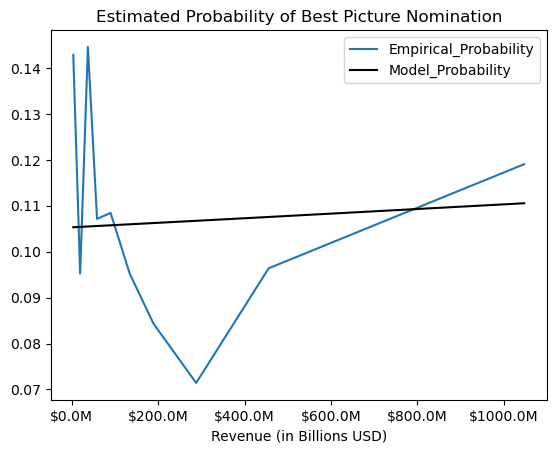

In [28]:
ax = nominee_summary.plot(x = 'Revenue', y = 'Empirical_Probability')
ax = nominee_summary.plot(x = 'Revenue', y = 'Model_Probability',
                color = 'black',
                ax = ax, 
                title = 'Estimated Probability of Best Picture Nomination',
                xlabel = 'Revenue (in Billions USD)');
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,pos: '$'+format(x/1000000)+'M'))

The logistic model does a poor job of approximating the empirical probability. The empirical probability varies widely as revenue increases from 0 to $400M.

In [29]:
# Empirical and estimated probabilities for revenue-drama model 
nominee_summary_drama = (
    movies
    .assign(Group = pd.qcut(movies[movies['Genre_Drama']==True]['Revenue'], 
                            q = 10, 
                            duplicates = 'drop'))
    .groupby('Group', observed = False)
    [['Revenue', 'Nominee']]
    .mean()
    .reset_index()
    .rename(columns = {'Nominee': 'Empirical_Probability'})
)

nominee_summary_drama['Genre_Drama']=True
nominee_summary_drama['Model_Probability'] = nominee_rev_drama_logreg.predict(exog=nominee_summary_drama[['Revenue','Genre_Drama']])

nominee_summary_drama

,Group,Revenue,Empirical_Probability,Genre_Drama,Model_Probability
0,"(1280.999, 4092886.8]",1.356722e+06,0.300000,True,0.226828
1,"(4092886.8, 15762824.6]",9.934459e+06,0.133333,True,0.229028
2,"(15762824.6, 27385960.6]",2.132457e+07,0.172414,True,0.231972
3,"(27385960.6, 39292309.6]",3.323833e+07,0.200000,True,0.235080
4,"(39292309.6, 52186426.0]",4.508826e+07,0.333333,True,0.238200
5,"(52186426.0, 75794517.4]",6.275984e+07,0.172414,True,0.242905
6,"(75794517.4, 116016348.4]",9.343934e+07,0.333333,True,0.251222
7,"(116016348.4, 172840384.2]",1.444047e+08,0.241379,True,0.265451
8,"(172840384.2, 322506836.4]",2.316495e+08,0.333333,True,0.290971
9,"(322506836.4, 1662020819.0]",5.983422e+08,0.400000,True,0.411872


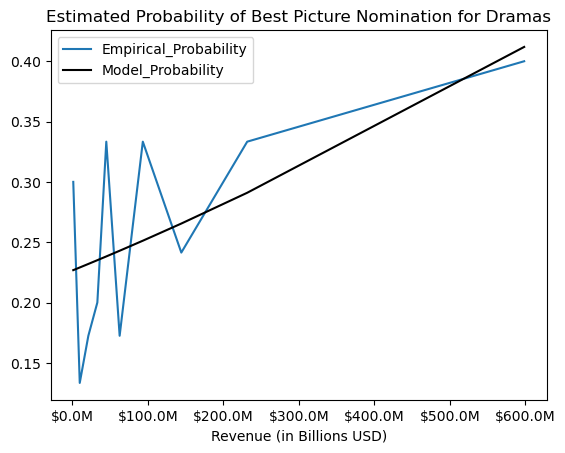

In [30]:
ax = nominee_summary_drama.plot(x = 'Revenue', y = 'Empirical_Probability')
ax = nominee_summary_drama.plot(x = 'Revenue', y = 'Model_Probability',
                color = 'black',
                ax = ax, 
                title = 'Estimated Probability of Best Picture Nomination for Dramas',
                xlabel = 'Revenue (in Billions USD)');
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,pos: '$'+format(x/1000000)+'M'))

In [31]:
nominee_summary_non_drama = (
    movies
    .assign(Group = pd.qcut(movies[movies['Genre_Drama']==False]['Revenue'], 
                            q = 10, 
                            duplicates = 'drop'))
    .groupby('Group', observed = False)
    [['Revenue', 'Nominee']]
    .mean()
    .reset_index()
    .rename(columns = {'Nominee': 'Empirical_Probability'})
)

nominee_summary_non_drama['Genre_Drama']=False
nominee_summary_non_drama['Model_Probability'] = nominee_rev_drama_logreg.predict(exog=nominee_summary_non_drama[['Revenue','Genre_Drama']])

nominee_summary_non_drama

,Group,Revenue,Empirical_Probability,Genre_Drama,Model_Probability
0,"(4999.999, 17734373.4]",7.658494e+06,0.018519,False,0.011003
1,"(17734373.4, 44651453.6]",3.100116e+07,0.018519,False,0.011379
2,"(44651453.6, 75353964.0]",5.872499e+07,0.000000,False,0.011843
3,"(75353964.0, 113140796.4]",9.200216e+07,0.000000,False,0.012424
4,"(113140796.4, 158261424.0]",1.345698e+08,0.037037,False,0.013209
5,"(158261424.0, 215669158.8]",1.842747e+08,0.000000,False,0.014187
6,"(215669158.8, 312274684.0]",2.575765e+08,0.018519,False,0.015761
7,"(312274684.0, 440166837.4]",3.785818e+08,0.037037,False,0.018744
8,"(440166837.4, 783449204.0]",5.855942e+08,0.018519,False,0.025179
9,"(783449204.0, 2799439100.0]",1.189414e+09,0.055556,False,0.058624


ax = nominee_summary_non_drama.plot(x = 'Revenue', y = 'Empirical_Probability')
ax = nominee_summary_non_drama.plot(x = 'Revenue', y = 'Model_Probability',
                color = 'black',
                ax = ax, 
                title = 'Estimated Probability of Best Picture Nomination for Non-Dramas',
                xlabel = 'Revenue (in Billions USD)');
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,pos: '$'+format(x/1000000)+'M'))

When incorporating drama/non-drama status into the logistic model, it does a much better job of approximating the empirical probability of a Best Picture nomination.

In [32]:
# Fitting a model using log revenue and drama status
nominee_logrev_drama_logreg = smf.logit("Nominee ~ I(np.log(Revenue)) + Genre_Drama",
                          data = movies).fit()

Optimization terminated successfully.
         Current function value: 0.267168
         Iterations 8


In [33]:
# Evaluating model strength based on AIC criterion

In [34]:
nominee_logrev_drama_logreg.aic

np.float64(452.70554627261924)

In [35]:
nominee_rev_drama_logreg.aic

np.float64(442.1130405555444)

AIC estimates the relative amount of information lost by a given model. This indicates that using the log of revenue in the model that also incorporates drama status makes the model slightly worse, in that it loses more information than the model that uses the raw revenue numbers.

In [36]:
# Evaluating model strength based on likelihood function

In [37]:
nominee_logrev_drama_logreg.llf

np.float64(-223.35277313630962)

In [38]:
nominee_rev_drama_logreg.llf

np.float64(-218.0565202777722)

A higher log likelihood function indicates a better model fit, so we see that the model that incorporates both revenue and drama status becomes slightly worse when we use log revenue.

In [39]:
# Fitting a model using log revenue and excluding drama status
nominee_logrev_logreg = smf.logit("Nominee ~ I(np.log(Revenue))",
                          data = movies).fit()

Optimization terminated successfully.
         Current function value: 0.337610
         Iterations 6


In [40]:
# Evaluating model strength based on AIC criterion

In [41]:
nominee_logrev_logreg.aic

np.float64(568.484062213854)

In [42]:
nominee_rev_logreg.aic

np.float64(570.8643256026157)

Using the log of revenue in the model that does not incorporate drama status makes the model slightly better, in that it loses less information than the model that uses the raw revenue numbers.

In [43]:
# Evaluating model strength based on likelihood function

In [44]:
nominee_logrev_logreg.llf

np.float64(-282.242031106927)

In [45]:
nominee_rev_logreg.llf

np.float64(-283.43216280130787)

The model using just revenue as the explanatory variable has a slightly higher log likelihood function value when we use log revenue.

In [75]:
nominee_rev_genres_reg = smf.logit("Nominee ~ Revenue + Genre_Action + Genre_Drama + Genre_Adventure",
                          data = movies).fit()

Optimization terminated successfully.
         Current function value: 0.250915
         Iterations 8


In [76]:
nominee_rev_genres_reg.params

Intercept                 -3.920757e+00
Genre_Action[T.True]      -1.273973e+00
Genre_Drama[T.True]        2.810955e+00
Genre_Adventure[T.True]   -9.946802e-01
Revenue                    2.127671e-09
dtype: float64

We see that a movie being an action or adventure movie decreases the odds that it will be nominated for an Oscar.

In [77]:
# Fitting a model for Best Picture nomination with profit
nominee_profit_logreg = smf.logit("Nominee ~ I(Revenue - Budget)",
                          data = movies).fit()

Optimization terminated successfully.
         Current function value: 0.338667
         Iterations 6


In [78]:
nominee_profit_logreg.params

Intercept             -2.177996e+00
I(Revenue - Budget)    2.924714e-10
dtype: float64

Revenue model params:

Intercept   -2.139634e+00
Revenue      5.196402e-11
dtype: float64


Comparing to the params of the revenue model, we see that profit has a greater effect on the probability of a movie being nominated for a Best Picture than revenue alone.